In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [4]:
df = pd.read_csv("Customer_churn_data.csv")

In [5]:
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [6]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Geography"].unique()

<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

In [10]:
df["Gender"].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [11]:
def find_outliers(df, column_name):
    
    # Check if column exists
    if column_name not in df.columns:
        print("Column not found.")
        return
    
    # Check if numeric
    if not df[column_name].dtype in ['int64', 'float64']:
        print("Column is not numeric.")
        return
    
    data = df[column_name].dropna()
    
    # Calculate quartiles
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Get outliers
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    
    print(f"\nColumn: {column_name}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    
    print("\nOutliers:")
    print(outliers)
    
    # Boxplot
    plt.figure(figsize=(6,4))
    plt.boxplot(data, vert=False)
    plt.title(f"Boxplot of {column_name}")
    plt.xlabel(column_name)
    plt.show()


Column: EstimatedSalary
Q1: 51002.11
Q3: 149388.2475
IQR: 98386.1375
Lower Bound: -96577.09624999999
Upper Bound: 296967.45375

Outliers:
Series([], Name: EstimatedSalary, dtype: float64)


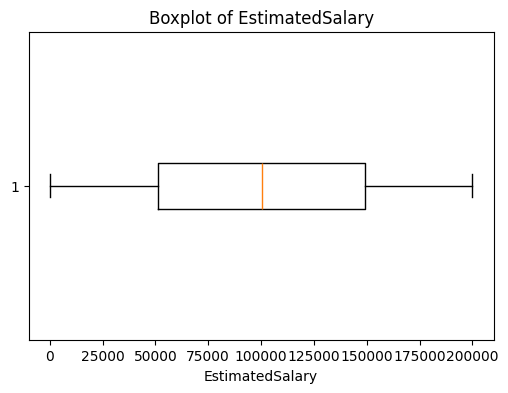

In [12]:
find_outliers(df, "EstimatedSalary")

In [13]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [14]:
df["Exited"].unique()

array([1, 0])

In [15]:
df["IsActiveMember"].unique()

array([1, 0])

In [16]:
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [17]:
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

In [18]:
df.head(10)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [19]:
X = df.drop("Exited" , axis = 1)
y = df["Exited"]

In [21]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size = 0.2 ,
    random_state = 42,
    stratify = y
)

In [26]:
X_train.shape


(8000, 10)

In [27]:
# --- 1) Preprocess: scale numeric + one-hot categorical (X_train/X_test already split) ---

import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# If you already have these, keep them:
# X_train, X_test, y_train, y_test

# Define column groups
numeric_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]
binary_cols  = ["HasCrCard", "IsActiveMember"]      # 0/1 ints (keep as is)
cat_cols     = ["Geography", "Gender"]

# Build preprocessing transformer
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),                      # scale numeric
        ("bin", "passthrough", binary_cols),                          # keep binary 0/1
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),    # one-hot encode categorical
    ],
    remainder="drop"
)

# Fit on training data, transform train and test
X_train_p = preprocess.fit_transform(X_train)
X_test_p  = preprocess.transform(X_test)

# OneHotEncoder often returns sparse matrix -> convert to dense for Keras
if hasattr(X_train_p, "toarray"):
    X_train_p = X_train_p.toarray()
    X_test_p  = X_test_p.toarray()

# Convert to float32 for TensorFlow
X_train_p = X_train_p.astype(np.float32)
X_test_p  = X_test_p.astype(np.float32)
y_train   = np.array(y_train).astype(np.float32)
y_test    = np.array(y_test).astype(np.float32)

print("Transformed train shape:", X_train_p.shape)
print("Transformed test  shape:", X_test_p.shape)



Transformed train shape: (8000, 13)
Transformed test  shape: (2000, 13)


In [29]:
type(X_train_p)

numpy.ndarray

In [30]:
from tensorflow.keras import regularizers

In [31]:

# --- 2) Build the Neural Network you requested: 6 -> 8 (ReLU), output sigmoid ---

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation="tanh",
          kernel_regularizer=regularizers.l2(0.001),
          input_shape=(X_train_p.shape[1],)),
    
    Dense(32, activation="tanh",
          kernel_regularizer=regularizers.l2(0.001)),
    
    Dense(16, activation="tanh",
          kernel_regularizer=regularizers.l2(0.001)),
    
    Dense(10, activation="tanh",
          kernel_regularizer=regularizers.l2(0.001)),
    
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# --- 3) Train using Batch Gradient Descent (full-batch) for 150 epochs ---

batch_size = 32   

history = model.fit(
    X_train_p, y_train,
    epochs=150,
    batch_size=batch_size,
    shuffle = True,
    validation_split=0.1,
    verbose=1
)

# --- 4) Evaluate on test set ---

test_loss, test_acc = model.evaluate(X_test_p, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

d:\Clustering Project ML\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/150
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8299 - loss: 0.4720 - val_accuracy: 0.8512 - val_loss: 0.4015
Epoch 2/150
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8489 - loss: 0.4111 - val_accuracy: 0.8525 - val_loss: 0.3894
Epoch 3/150
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8482 - loss: 0.4060 - val_accuracy: 0.8700 - val_loss: 0.3569
Epoch 4/150
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8447 - loss: 0.3983 - val_accuracy: 0.8650 - val_loss: 0.3614
Epoch 5/150
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8485 - loss: 0.3901 - val_accuracy: 0.8700 - val_loss: 0.3582
Epoch 6/150
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8531 - loss: 0.3866 - val_accuracy: 0.8675 - val_loss: 0.3483
Epoch 7/150
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8503 - loss: 0.3867 - val_accuracy: 0.8687 - val_loss: 0.3555
Epoch 8/150
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8521 - loss: 0.3818 - val_acc

In [32]:
# ---- CELL 1: Track underfitting/overfitting using loss + accuracy ----

# 1) Final training metrics from the last epoch
train_loss_last = history.history["loss"][-1]
train_acc_last  = history.history["accuracy"][-1]

# 2) Evaluate on full training set (more reliable than validation_split)
train_loss_full, train_acc_full = model.evaluate(X_train_p, y_train, verbose=0)

# 3) Evaluate on test set
test_loss, test_acc = model.evaluate(X_test_p, y_test, verbose=0)

print("=== Last epoch (training only) ===")
print(f"Train Loss (last epoch): {train_loss_last:.4f}")
print(f"Train Acc  (last epoch): {train_acc_last:.4f}")

print("\n=== Full dataset evaluation ===")
print(f"Train Loss (full train set): {train_loss_full:.4f}")
print(f"Train Acc  (full train set): {train_acc_full:.4f}")
print(f"Test  Loss:                {test_loss:.4f}")
print(f"Test  Acc:                 {test_acc:.4f}")

print("\n=== Quick diagnosis idea ===")
print("If Train performance is poor -> UNDERFITTING (high bias).")
print("If Train good but Test bad -> OVERFITTING (high variance).")
print("If both good and close -> Good generalization.")

=== Last epoch (training only) ===
Train Loss (last epoch): 0.3612
Train Acc  (last epoch): 0.8576

=== Full dataset evaluation ===
Train Loss (full train set): 0.3593
Train Acc  (full train set): 0.8636
Test  Loss:                0.3587
Test  Acc:                 0.8665

=== Quick diagnosis idea ===
If Train performance is poor -> UNDERFITTING (high bias).
If Train good but Test bad -> OVERFITTING (high variance).
If both good and close -> Good generalization.


In [33]:
# ---- CELL 2: Accuracy, Precision, Recall, F1, Confusion Matrix ----

import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluate_classification(model, X, y_true, threshold=0.5, name="SET"):
    # Predict probabilities
    probs = model.predict(X, verbose=0).ravel()
    # Convert to 0/1 predictions
    y_pred = (probs >= threshold).astype(int)
    y_true_int = y_true.astype(int)

    acc = accuracy_score(y_true_int, y_pred)
    prec = precision_score(y_true_int, y_pred, zero_division=0)
    rec = recall_score(y_true_int, y_pred, zero_division=0)
    f1 = f1_score(y_true_int, y_pred, zero_division=0)
    cm = confusion_matrix(y_true_int, y_pred)

    print(f"\n==== {name} RESULTS (threshold={threshold}) ====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_true_int, y_pred, digits=4, zero_division=0))

    return {"acc": acc, "precision": prec, "recall": rec, "f1": f1, "cm": cm}

# Evaluate on training set
train_metrics = evaluate_classification(model, X_train_p, y_train, name="TRAIN")

# Evaluate on test set
test_metrics = evaluate_classification(model, X_test_p, y_test, name="TEST")


==== TRAIN RESULTS (threshold=0.5) ====
Accuracy : 0.8636
Precision: 0.8116
Recall   : 0.4307
F1-score : 0.5627

Confusion Matrix:
[[6207  163]
 [ 928  702]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8699    0.9744    0.9192      6370
           1     0.8116    0.4307    0.5627      1630

    accuracy                         0.8636      8000
   macro avg     0.8407    0.7025    0.7410      8000
weighted avg     0.8580    0.8636    0.8466      8000


==== TEST RESULTS (threshold=0.5) ====
Accuracy : 0.8665
Precision: 0.8182
Recall   : 0.4423
F1-score : 0.5742

Confusion Matrix:
[[1553   40]
 [ 227  180]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8725    0.9749    0.9208      1593
           1     0.8182    0.4423    0.5742       407

    accuracy                         0.8665      2000
   macro avg     0.8453    0.7086    0.7475      2000
weighted avg     0.8614    0.8665   

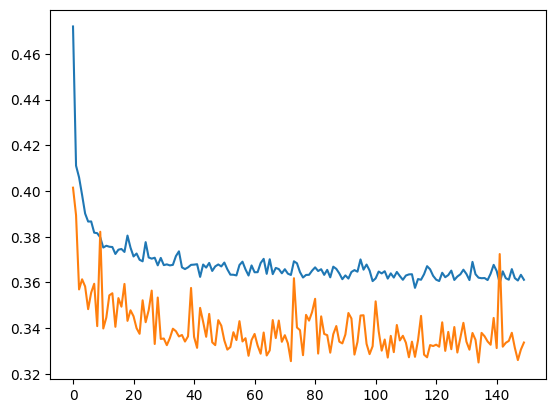

In [34]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.show()

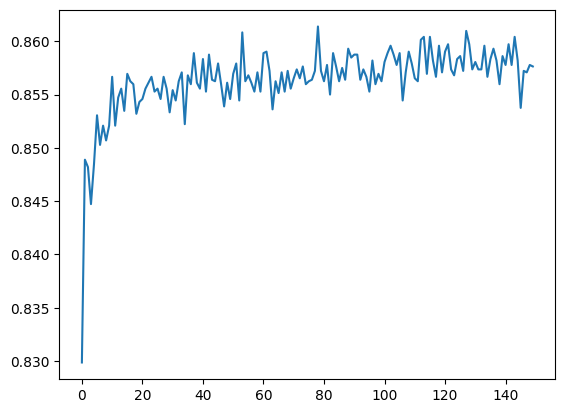

In [35]:
plt.plot(history.history["accuracy"])